### Processing EMTP-RV outputs

In [1]:
import pickle

In [2]:
from simulation import Simulation

In [3]:
from utils import create_white_list
from utils import plot_machine_signals, plot_machine_delta_signals
from utils import plot_bus_voltages_rms, plot_bus_voltage_dir
from utils import tsi_from_angle, tsi_from_omega

In [4]:
# EMTP file name (without extension):
name = 'IEEE39_Wind_v5_17_4_2026_Dino'

# Create a list of variable names:
varnames = [
    '/Teta_1_SM1',
    '/Omega_1_SM1',
    '/Pe_SM1',
]
# List of machines that are excluded.
exclude = [8, 10]
# List of bus voltages.
buses = [2, 3, 25, 29]

In [5]:
white_list = create_white_list(varnames, exclude, buses)
white_list

['BUS2/Vrms_a',
 'BUS2/Vrms_b',
 'BUS2/Vrms_c',
 'BUS2/V1_mag',
 'BUS2/V1_phase',
 'BUS3/Vrms_a',
 'BUS3/Vrms_b',
 'BUS3/Vrms_c',
 'BUS3/V1_mag',
 'BUS3/V1_phase',
 'BUS25/Vrms_a',
 'BUS25/Vrms_b',
 'BUS25/Vrms_c',
 'BUS25/V1_mag',
 'BUS25/V1_phase',
 'BUS29/Vrms_a',
 'BUS29/Vrms_b',
 'BUS29/Vrms_c',
 'BUS29/V1_mag',
 'BUS29/V1_phase',
 'PowerPlant_01/Teta_1_SM1',
 'PowerPlant_02/Teta_1_SM1',
 'PowerPlant_03/Teta_1_SM1',
 'PowerPlant_04/Teta_1_SM1',
 'PowerPlant_05/Teta_1_SM1',
 'PowerPlant_06/Teta_1_SM1',
 'PowerPlant_07/Teta_1_SM1',
 'PowerPlant_09/Teta_1_SM1',
 'PowerPlant_01/Omega_1_SM1',
 'PowerPlant_02/Omega_1_SM1',
 'PowerPlant_03/Omega_1_SM1',
 'PowerPlant_04/Omega_1_SM1',
 'PowerPlant_05/Omega_1_SM1',
 'PowerPlant_06/Omega_1_SM1',
 'PowerPlant_07/Omega_1_SM1',
 'PowerPlant_09/Omega_1_SM1',
 'PowerPlant_01/Pe_SM1',
 'PowerPlant_02/Pe_SM1',
 'PowerPlant_03/Pe_SM1',
 'PowerPlant_04/Pe_SM1',
 'PowerPlant_05/Pe_SM1',
 'PowerPlant_06/Pe_SM1',
 'PowerPlant_07/Pe_SM1',
 'PowerPlant_09

In [6]:
# Assemble .m and .mda files.
m_file = name + 'm.m'
mda_file = name + '.mda'

In [7]:
# Read the simulation .mda file.
sim = Simulation(mda_file, m_file, white_list)
sim.load_data()

In [8]:
# Export signals to DataFrame.
data = sim.to_dataframe()
data

,time,BUS2/Vrms_a,BUS2/Vrms_b,BUS2/Vrms_c,BUS2/V1_mag,BUS2/V1_phase,BUS3/Vrms_a,BUS3/Vrms_b,BUS3/Vrms_c,BUS3/V1_mag,...,PowerPlant_07/Omega_1_SM1,PowerPlant_09/Omega_1_SM1,PowerPlant_01/Pe_SM1,PowerPlant_02/Pe_SM1,PowerPlant_03/Pe_SM1,PowerPlant_04/Pe_SM1,PowerPlant_05/Pe_SM1,PowerPlant_06/Pe_SM1,PowerPlant_07/Pe_SM1,PowerPlant_09/Pe_SM1
0,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,999.985355,0.587792,649.990439,631.990707,507.992534,649.990433,559.991773,0.829988
1,0.002,0.461115,0.163269,0.339911,0.119134,-7.330885,0.457900,0.178888,0.316720,0.116959,...,1.000000,1.000000,1000.667877,0.587793,650.128627,632.116815,507.985005,649.769752,559.310737,0.829930
2,0.004,0.534631,0.288574,0.584098,0.238374,-7.342731,0.538956,0.278873,0.562118,0.233961,...,1.000000,1.000000,1000.799280,0.587833,649.967046,631.756239,507.767852,649.735153,560.375831,0.829402
3,0.006,0.551467,0.534613,0.689837,0.357626,-7.336794,0.551884,0.515185,0.675706,0.350982,...,1.000000,1.000000,999.881323,0.587629,649.853340,631.909541,507.952477,649.716589,559.671188,0.829563
4,0.008,0.674824,0.690314,0.699459,0.476850,-7.331428,0.662969,0.675939,0.687315,0.467987,...,1.000000,1.000000,999.736328,0.587938,650.005881,631.738542,507.841771,649.699940,559.638386,0.829794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,3.992,0.988332,0.987492,0.987628,0.987814,26.459995,0.969868,0.968908,0.968965,0.969242,...,0.999804,0.999841,921.577389,0.589904,653.290881,635.508675,513.338986,653.887798,561.035537,0.833965
1997,3.994,0.988465,0.987397,0.987639,0.987830,26.451690,0.970002,0.968819,0.968954,0.969254,...,0.999803,0.999840,920.805646,0.589536,652.854115,635.095285,513.269128,653.626752,562.277253,0.832423
1998,3.996,0.988427,0.987338,0.987786,0.987847,26.443378,0.969977,0.968742,0.969095,0.969267,...,0.999801,0.999838,922.762163,0.589577,653.115404,635.652615,513.580945,654.259772,562.197466,0.834394
1999,3.998,0.988322,0.987451,0.987825,0.987863,26.435277,0.969862,0.968843,0.969146,0.969279,...,0.999799,0.999836,925.227661,0.589990,653.793948,635.749994,514.025629,654.802040,562.813765,0.835174


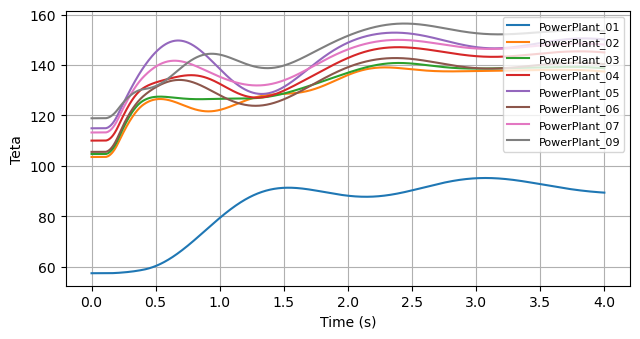

In [9]:
# Plot machine "Theta" values.
plot_machine_signals(data, 'Teta')

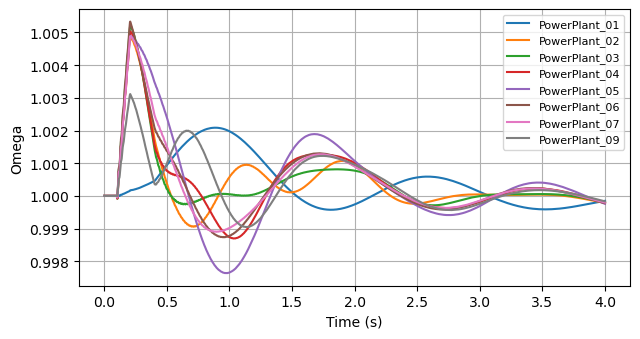

In [10]:
# Plot machine "Omega" values.
plot_machine_signals(data, 'Omega')

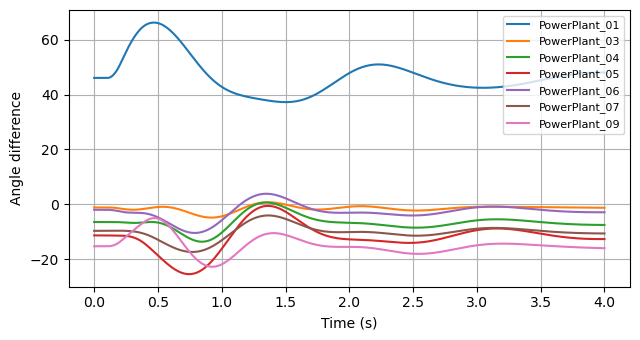

In [11]:
# Machine swing angles with regards to the slack bus.
plot_machine_delta_signals(data)

In [ ]:
# Transient stability index.
sim_tsi = tsi_from_angle(data)
print(f'TSI = {sim_tsi}')
sim_tsi = tsi_from_omega(data)
print(f'TSI = {sim_tsi}')

TSI = 0
TSI = 0


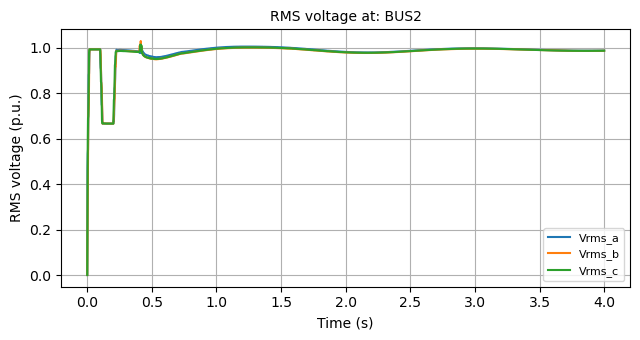

In [13]:
plot_bus_voltages_rms(data, 'BUS2')

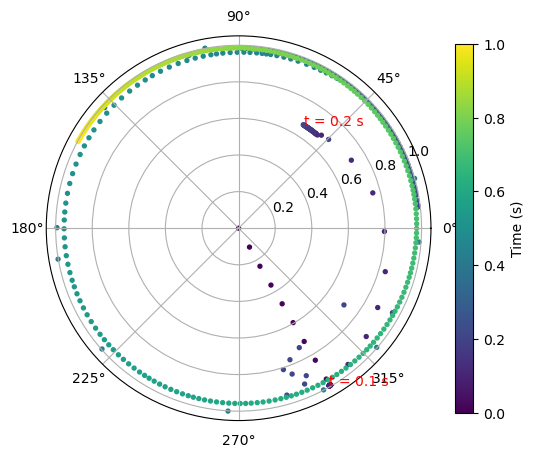

In [14]:
# The first second of the direct sequence BUS2 voltage 
# on a time-annotated polar plot.
plot_bus_voltage_dir(data, 'BUS2', limit=1)

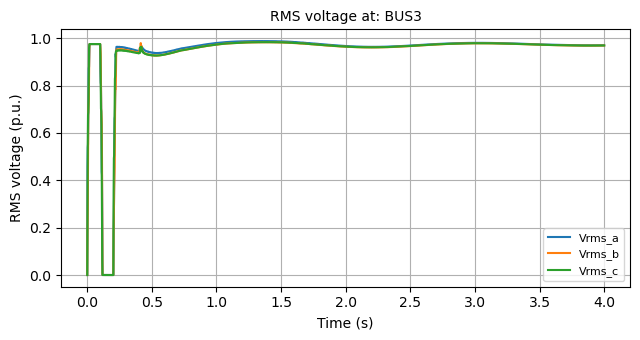

In [15]:
plot_bus_voltages_rms(data, 'BUS3')

### Reading external pickle file with simulation signals

In [16]:
with open(file='SC3.pkl', mode='rb') as fp:
    data = pickle.load(fp)

In [17]:
data.keys()

dict_keys(['SC3BUS0', 'SC3BUS1', 'SC3BUS2', 'SC3BUS3', 'SC3BUS4', 'SC3BUS5', 'SC3BUS6', 'SC3BUS7', 'SC3BUS8', 'SC3BUS9'])

In [18]:
# Extract DataFrame for a select simulation case.
data_bus1 = data['SC3BUS3']
data_bus1

,time,BUS2/Vrms_a,BUS2/Vrms_b,BUS2/Vrms_c,BUS2/V1_mag,BUS2/V1_phase,BUS3/Vrms_a,BUS3/Vrms_b,BUS3/Vrms_c,BUS3/V1_mag,...,PowerPlant_07/Teta_1_SM1,PowerPlant_09/Teta_1_SM1,PowerPlant_01/Omega_1_SM1,PowerPlant_02/Omega_1_SM1,PowerPlant_03/Omega_1_SM1,PowerPlant_04/Omega_1_SM1,PowerPlant_05/Omega_1_SM1,PowerPlant_06/Omega_1_SM1,PowerPlant_07/Omega_1_SM1,PowerPlant_09/Omega_1_SM1
0,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,113.234267,118.875851,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.002,0.461115,0.163269,0.339911,0.119134,-7.330885,0.457900,0.178888,0.316720,0.116959,...,113.234268,118.875851,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.004,0.534631,0.288574,0.584098,0.238374,-7.342731,0.538956,0.278873,0.562118,0.233961,...,113.234271,118.875856,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.006,0.551467,0.534613,0.689837,0.357626,-7.336794,0.551884,0.515185,0.675706,0.350982,...,113.234277,118.875863,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.008,0.674824,0.690314,0.699459,0.476850,-7.331428,0.662969,0.675939,0.687315,0.467987,...,113.234285,118.875873,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,3.992,0.989772,0.989946,0.989778,0.989832,17.423830,0.971403,0.971587,0.971431,0.971473,...,138.988490,144.349119,0.999813,0.999762,0.999794,0.999728,0.999673,0.999724,0.999738,0.999765
1997,3.994,0.989944,0.989864,0.989732,0.989846,17.413771,0.971574,0.971516,0.971363,0.971484,...,138.977152,144.338957,0.999814,0.999760,0.999792,0.999726,0.999670,0.999723,0.999737,0.999764
1998,3.996,0.989947,0.989742,0.989898,0.989862,17.403191,0.971593,0.971382,0.971513,0.971496,...,138.965773,144.328743,0.999815,0.999758,0.999790,0.999725,0.999668,0.999722,0.999736,0.999763
1999,3.998,0.989803,0.989837,0.989994,0.989878,17.393066,0.971443,0.971456,0.971623,0.971507,...,138.954350,144.318473,0.999816,0.999756,0.999789,0.999723,0.999666,0.999721,0.999735,0.999762


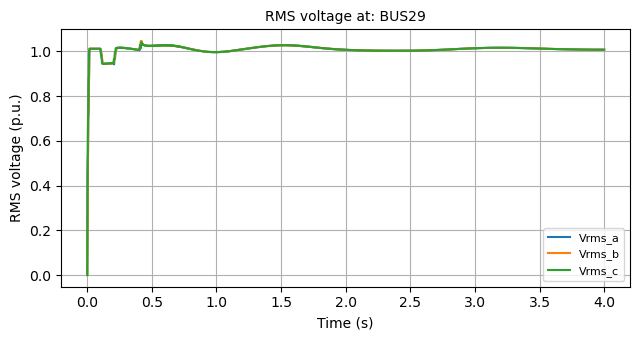

In [19]:
plot_bus_voltages_rms(data_bus1, 'BUS29')